In [1]:
import os
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
import tensorflow as tf

I0000 00:00:1786487998.146342  219011 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
from tensorflow.keras import backend as K
K.clear_session()

In [3]:
import numpy as np
import tensorflow as tf
import random
import seaborn as sns
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import image_dataset_from_directory
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from data.data import load_dataset
import evaluate

/home/rynoko/projects/MRI-GPU/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

In [5]:
random.seed(SEED)
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [6]:
X, y, X_test, y_test = load_dataset()

Loading cached dataset from data/dataset_rgb.npz...


In [7]:
print(f'X shape:{X.shape}, y shape:{y.shape}, X_test shape:{X_test.shape}')

X shape:(5600, 224, 224, 3), y shape:(5600,), X_test shape:(1600, 224, 224, 3)


In [8]:
X_train , X_val , y_train , y_val = train_test_split(X, y, test_size=0.2, random_state=42 , stratify=y)

In [9]:
X_train.shape , y_train.shape , X_val.shape , y_val.shape

((4480, 224, 224, 3), (4480,), (1120, 224, 224, 3), (1120,))

In [10]:
cnn = Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Rescaling(1./255),


    layers.Conv2D(32, (3,3), padding='same', activation='relu',name='conv2d_0'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding='same', activation='relu',name='conv2d_1'),
    layers.Dropout(0.25),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), padding='same', activation='relu',name='conv2d_2'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(4, activation='softmax')
])

I0000 00:00:1786488010.832552  219011 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1786488010.834227  219011 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2409 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [11]:
cnn.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [12]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [13]:
def data_generator(X, y, batch_size):
    n = len(X)
    while True:
        idx = np.random.permutation(n)
        for i in range(0, n, batch_size):
            batch_idx = idx[i:i+batch_size]
            yield X[batch_idx], y[batch_idx]

train_ds = tf.data.Dataset.from_generator(
    lambda: data_generator(X_train, y_train, batch_size=8),
    output_signature=(
        tf.TensorSpec(shape=(None, *X_train.shape[1:]), dtype=tf.float32),
        tf.TensorSpec(shape=(None, *y_train.shape[1:]), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_generator(
    lambda: data_generator(X_val, y_val, batch_size=8),
    output_signature=(
        tf.TensorSpec(shape=(None, *X_val.shape[1:]), dtype=tf.float32),
        tf.TensorSpec(shape=(None, *y_val.shape[1:]), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_generator(
    lambda: data_generator(X_test, y_test, batch_size=8),
    output_signature=(
        tf.TensorSpec(shape=(None, *X_test.shape[1:]), dtype=tf.float32),
        tf.TensorSpec(shape=(None, *y_test.shape[1:]), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)


In [14]:
history = cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    steps_per_epoch=len(X_train) // 8,
    validation_steps=len(X_val) // 8,
    callbacks=[early_stop]
)


test_loss, test_acc = cnn.evaluate(test_ds, steps=len(X_test) // 8)

Epoch 1/20


/home/rynoko/projects/MRI-GPU/venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1786488011.710347  219011 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1786488012.682614  219138 service.cc:153] XLA service 0x7702ec033f00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786488012.682641  219138 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1786488012.719174  219138 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00

  7/560 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.2500 - loss: 1.6665

I0000 00:00:1786488019.669690  219138 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


560/560 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - accuracy: 0.6902 - loss: 0.7516 - val_accuracy: 0.7536 - val_loss: 0.5545
Epoch 2/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.8373 - loss: 0.4318 - val_accuracy: 0.8580 - val_loss: 0.4170
Epoch 3/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.8958 - loss: 0.2869 - val_accuracy: 0.8848 - val_loss: 0.3313
Epoch 4/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9324 - loss: 0.1948 - val_accuracy: 0.8795 - val_loss: 0.3332
Epoch 5/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9491 - loss: 0.1380 - val_accuracy: 0.9134 - val_loss: 0.2741
Epoch 6/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9603 - loss: 0.1114 - val_accuracy: 0.9241 - val_loss: 0.2756
Epoch 7/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9699 - loss: 0.0874 - val_accuracy: 0.9268 - val_loss: 0.2721
Epoch 8/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9777 - loss: 0.0640 - val_accurac

In [15]:
print(f'Accuracy: {test_acc:.2f}, Loss: {test_loss:.2f}')

Accuracy: 0.87, Loss: 0.94


In [16]:
CLASS_NAMES = ["notumor", "glioma", "meningioma", "pituitary"]

W0000 00:00:1786488150.036151  219011 cpu_allocator_impl.cc:82] Allocation of 963379200 exceeds 10% of free system memory.
W0000 00:00:1786488151.031559  219011 cpu_allocator_impl.cc:82] Allocation of 963379200 exceeds 10% of free system memory.


50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step
Classification Report:
               precision    recall  f1-score   support

     notumor     0.8156    0.9950    0.8964       400
      glioma     0.9016    0.6875    0.7801       400
  meningioma     0.8066    0.8550    0.8301       400
   pituitary     0.9687    0.9275    0.9476       400

    accuracy                         0.8662      1600
   macro avg     0.8731    0.8662    0.8636      1600
weighted avg     0.8731    0.8662    0.8636      1600



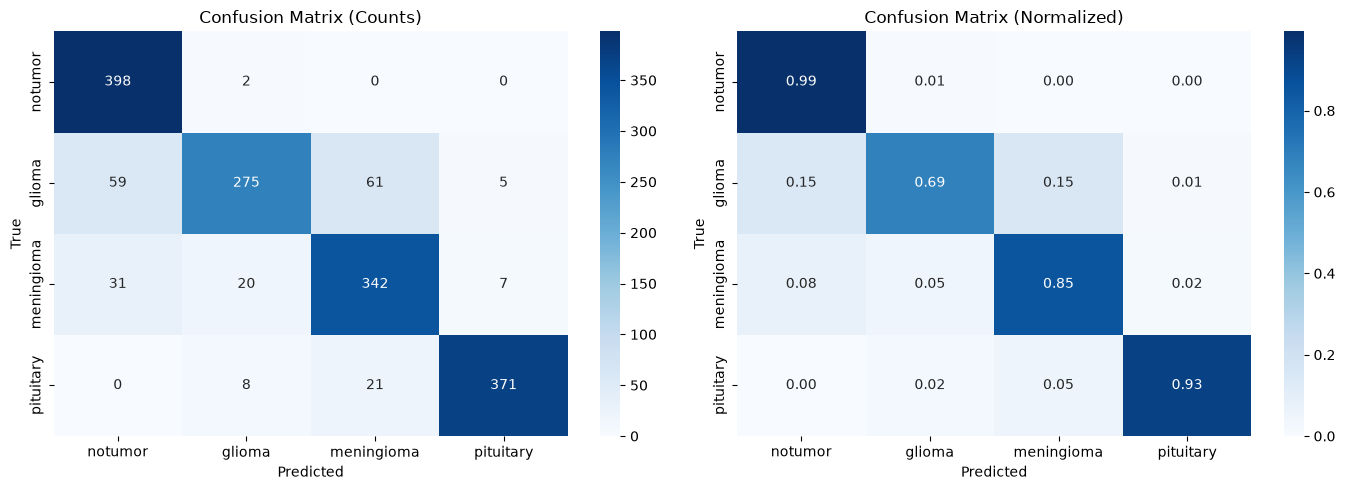

Macro-averaged AUC (OvR): 0.9591


W0000 00:00:1786488156.276569  219011 cpu_allocator_impl.cc:82] Allocation of 674365440 exceeds 10% of free system memory.
W0000 00:00:1786488156.900355  219011 cpu_allocator_impl.cc:82] Allocation of 674365440 exceeds 10% of free system memory.


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


W0000 00:00:1786488158.344530  219011 cpu_allocator_impl.cc:82] Allocation of 963379200 exceeds 10% of free system memory.


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
notumor - val precision: 0.9431, test precision: 0.8156
glioma - val precision: 0.9502, test precision: 0.9016
meningioma - val precision: 0.8464, test precision: 0.8066
pituitary - val precision: 0.9614, test precision: 0.9687


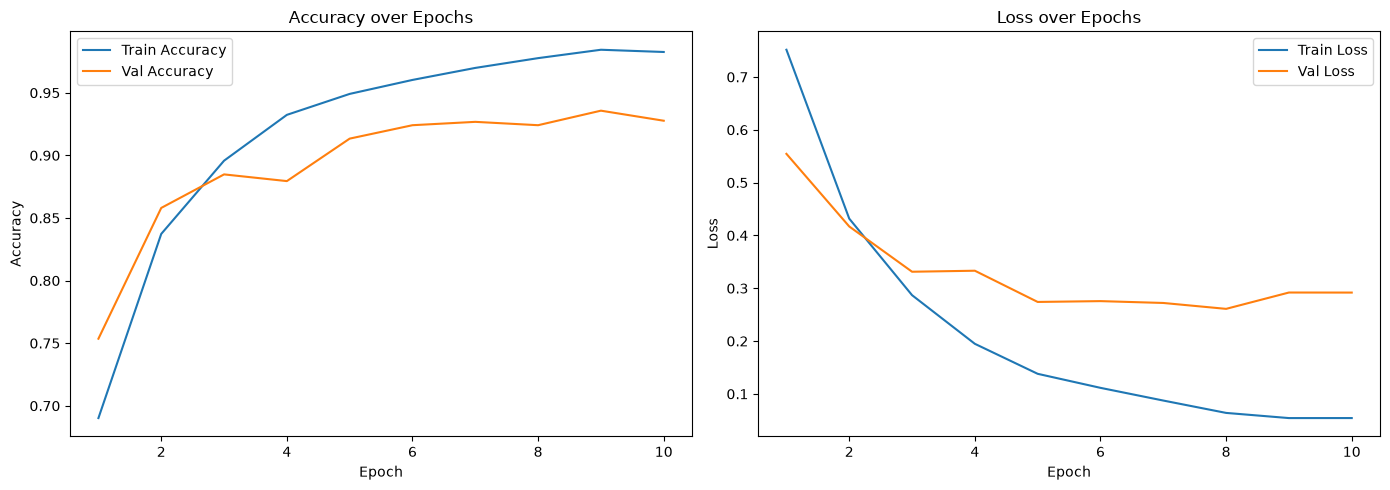

In [17]:
results = evaluate.evaluate_model(cnn, X_test, y_test, class_names=CLASS_NAMES, save_prefix="Base_CNN")
evaluate.evaluate_per_class(cnn,X_val, X_test, y_val, y_test, CLASS_NAMES)
evaluate.plot_training_curves(history, save_prefix="efficientNetBO")

cnn.save("models/BaseCNN_mri_tumor.keras")

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


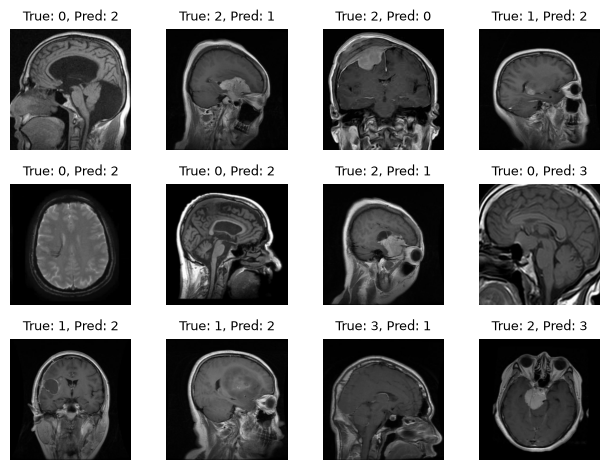


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


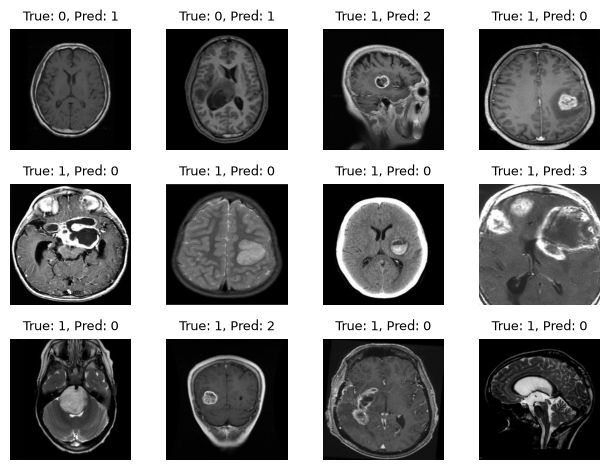

In [18]:
evaluate.plot_false_preds(cnn, X_val, y_val,'base-cnn')
print()
evaluate.plot_false_preds(cnn, X_test, y_test,'base-cnn')

[BaseCNN_mri_tumor] 214 wrong predictions out of 1600 (showing first 12)


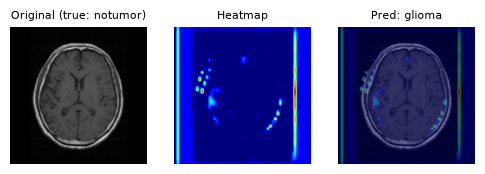

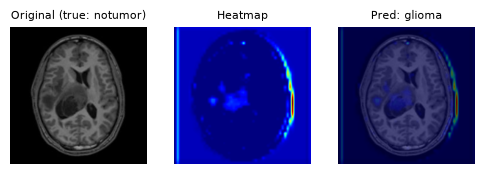

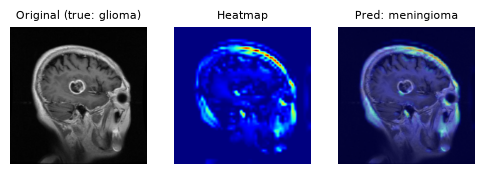

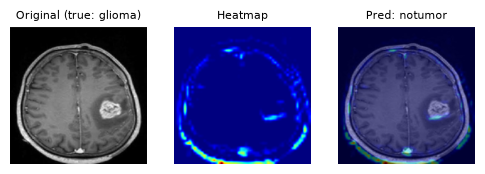

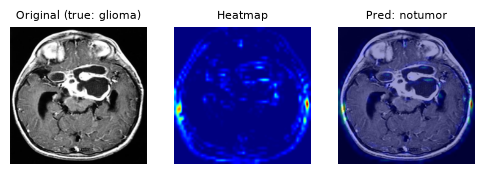

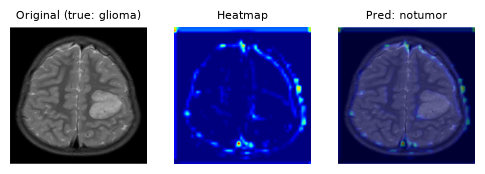

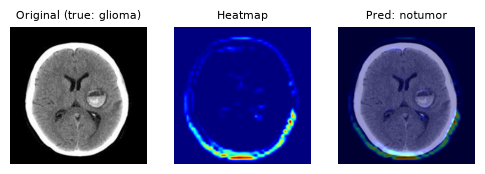

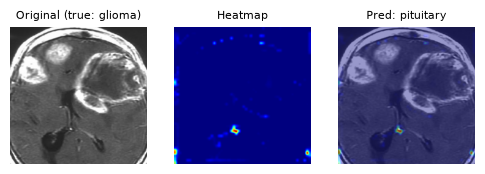

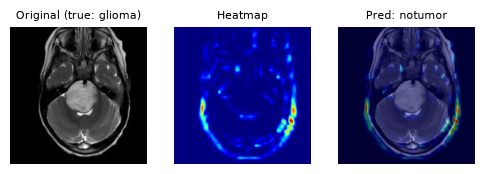

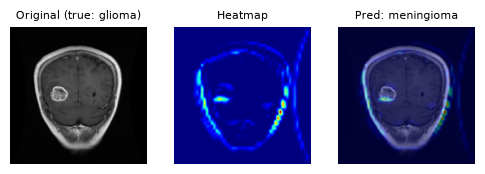

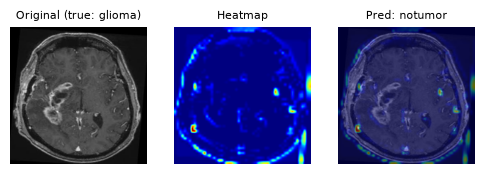

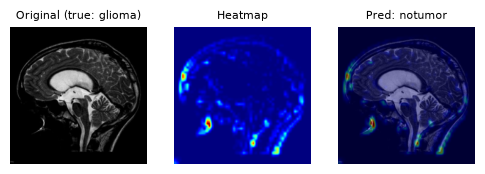

In [22]:
from gradcam import get_models, prep_grad_model, run_for_model

models = get_models()
gradCam_models = {name: prep_grad_model(obj, name) for name, obj in models.items()}
run_for_model("BaseCNN_mri_tumor", models, gradCam_models,max_examples=12)


In [23]:
from keras.models import load_model

model = load_model('models/BaseCNN_mri_tumor.keras')
